In [5]:
import pandas as pd
import glob
import os

path = "raw_bench_results/"
all_files = glob.glob(os.path.join(path, "*.csv"))

df_list = []
for filename in all_files:
    df = pd.read_csv(filename)
    df_list.append(df)

final_df = pd.concat(df_list, axis=0, ignore_index=True)

output_path = "final_benchmark_results.csv"
final_df.to_csv(output_path, index=False)

/tmp/ipykernel_64540/1883544273.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique['Safety_Zone'] = pd.cut(df_unique['Rej_99p'], bins=bins, labels=labels)


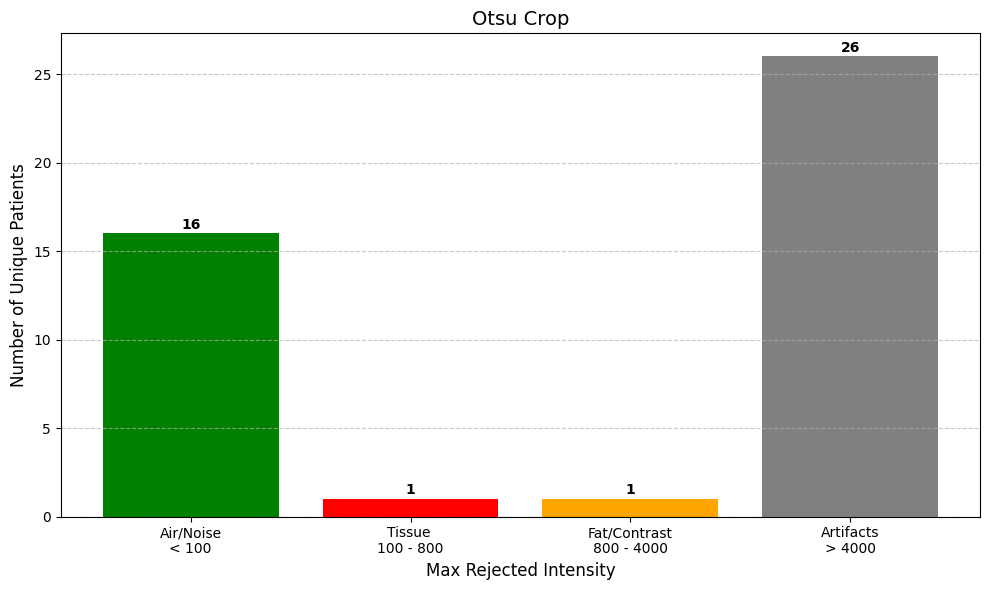

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df_unique = final_df.drop_duplicates(subset=['File'])

bins = [-1, 100, 800, 4000, np.inf]
labels = ['Air/Noise\n< 100', 'Tissue \n100 - 800', 'Fat/Contrast\n800 - 4000', 'Artifacts\n> 4000']

df_unique['Safety_Zone'] = pd.cut(df_unique['Rej_99p'], bins=bins, labels=labels)

counts = df_unique['Safety_Zone'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
bars = plt.bar(counts.index, counts.values, color=['green', 'red', 'orange', 'gray'])

plt.title(f"Otsu Crop", fontsize=14)
plt.ylabel("Number of Unique Patients", fontsize=12)
plt.xlabel("Max Rejected Intensity", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    if yval > 0:
        plt.text( bar.get_x() + bar.get_width()/2,  yval + 0.1, int(yval), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [27]:
mask = (final_df["Rej_99p"] > 100 ) & ( final_df["Rej_99p"] < 800)
print(final_df[mask][["Rej_99p","Rej_95p"]])

gain = df_unique["VRR"].mean() * 100 

print(f"Average Volume Reduction Rate on Unique Patients: {gain:.2f} %")

     Rej_99p  Rej_95p
234    119.0     71.0
235    119.0     71.0
236    119.0     71.0
237    119.0     71.0
238    119.0     71.0
239    119.0     71.0
Average Volume Reduction Rate on Unique Patients: 31.58 %


On average, Otsu's method allowed us to reduce image volume by 32%, which is a significant optimization. The only minor concern was a single DCE scan where the crop threshold was set at an intensity of 119; I will investigate this specific case further, but overall, this strategy ensures the model is trained strictly on relevant anatomical information rather than noise or non-tissue background pixels.

In [33]:
final_df.groupby(["Reg_Type" , "Sampling_Rate"]).agg(avg_time = ("Time_sec" , "mean"),
                                                     ref_drift = ("Ref_Drift_mm" , "mean"), 
                                                     avg_stability = ("Stability_Err_mm" , "mean"))

avg_time  ref_drift  avg_stability
Reg_Type Sampling_Rate                                     
BSpline  0.01           10.223432   0.009545       0.000705
         0.05           42.281705   0.009545       0.000136
         0.10           81.155841   0.009545       0.000091
Rigid    0.01            3.393864   7.385455       1.269023
         0.05            8.168636   7.385455       0.377841
         0.10           14.106000   7.385455       0.228909

Preliminary benchmarks indicate that B spline non rigid registration outperforms rigid methods. Although the breast is mechanically immobilized within the MRI coil, physiological factors such as breathing introduce deformations that rigid registration cannot fully correct. A visual assessment is now required to validate these findings and confirm the stability of the non rigid approach